In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from my_functions import *

sns.set_theme()
gc.enable()

In [3]:
prev_data=pd.read_csv('previous_application.csv')
prev_data.shape

(1670214, 37)

In [4]:
prev_data.dtypes

SK_ID_PREV                       int64
SK_ID_CURR                       int64
NAME_CONTRACT_TYPE              object
AMT_ANNUITY                    float64
AMT_APPLICATION                float64
AMT_CREDIT                     float64
AMT_DOWN_PAYMENT               float64
AMT_GOODS_PRICE                float64
WEEKDAY_APPR_PROCESS_START      object
HOUR_APPR_PROCESS_START          int64
FLAG_LAST_APPL_PER_CONTRACT     object
NFLAG_LAST_APPL_IN_DAY           int64
RATE_DOWN_PAYMENT              float64
RATE_INTEREST_PRIMARY          float64
RATE_INTEREST_PRIVILEGED       float64
NAME_CASH_LOAN_PURPOSE          object
NAME_CONTRACT_STATUS            object
DAYS_DECISION                    int64
NAME_PAYMENT_TYPE               object
CODE_REJECT_REASON              object
NAME_TYPE_SUITE                 object
NAME_CLIENT_TYPE                object
NAME_GOODS_CATEGORY             object
NAME_PORTFOLIO                  object
NAME_PRODUCT_TYPE               object
CHANNEL_TYPE             

In [5]:
prev_data.isnull().sum()*100/prev_data.shape[0]

SK_ID_PREV                      0.000000
SK_ID_CURR                      0.000000
NAME_CONTRACT_TYPE              0.000000
AMT_ANNUITY                    22.286665
AMT_APPLICATION                 0.000000
AMT_CREDIT                      0.000060
AMT_DOWN_PAYMENT               53.636480
AMT_GOODS_PRICE                23.081773
WEEKDAY_APPR_PROCESS_START      0.000000
HOUR_APPR_PROCESS_START         0.000000
FLAG_LAST_APPL_PER_CONTRACT     0.000000
NFLAG_LAST_APPL_IN_DAY          0.000000
RATE_DOWN_PAYMENT              53.636480
RATE_INTEREST_PRIMARY          99.643698
RATE_INTEREST_PRIVILEGED       99.643698
NAME_CASH_LOAN_PURPOSE          0.000000
NAME_CONTRACT_STATUS            0.000000
DAYS_DECISION                   0.000000
NAME_PAYMENT_TYPE               0.000000
CODE_REJECT_REASON              0.000000
NAME_TYPE_SUITE                49.119754
NAME_CLIENT_TYPE                0.000000
NAME_GOODS_CATEGORY             0.000000
NAME_PORTFOLIO                  0.000000
NAME_PRODUCT_TYP

In [6]:
numerical_frame=prev_data.select_dtypes(exclude=object)
categorical_frame=prev_data.select_dtypes(include=object)
categorical_frame['SK_ID_PREV']=prev_data['SK_ID_PREV']
categorical_frame['SK_ID_CURR']=prev_data['SK_ID_CURR']

In [7]:
numerical_frame=numerical_frame[['SK_ID_CURR', 'SK_ID_PREV', 
                                 'AMT_DOWN_PAYMENT', 'CNT_PAYMENT',
                                 'RATE_DOWN_PAYMENT', 'SELLERPLACE_AREA']]
categorical_frame=categorical_frame[['SK_ID_CURR', 'SK_ID_PREV', 
                                     'CHANNEL_TYPE', 'CODE_REJECT_REASON',
                                     'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION']]


### Aggregation

#### Numerical

In [8]:
agg_data=numerical_frame.groupby(by='SK_ID_CURR').agg(func=['min', 'max', 'median'])
agg_data.columns=pd.Index(['_'.join(val) for val in agg_data.columns.to_flat_index()])
agg_data.drop(labels=['SK_ID_PREV_min', 'SK_ID_PREV_max', 'SK_ID_PREV_median'], axis=1, inplace=True)
agg_data.reset_index(inplace=True)
agg_data.shape

(338857, 13)

In [9]:
'''
adding target column
<main_data_id_target> contains target for each current loan
'''
main_data_id_target=pd.read_csv('application_train.csv',usecols=['SK_ID_CURR', 'TARGET']) 
agg_target=pd.merge(left=agg_data, right=main_data_id_target, on='SK_ID_CURR')
agg_target.shape

(291057, 14)

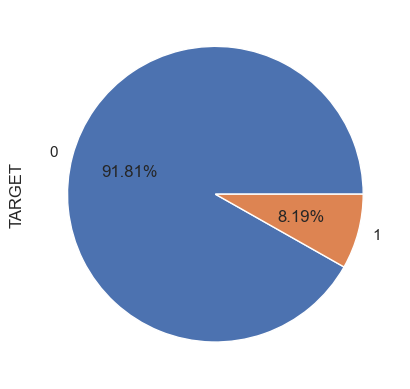

In [10]:
'''
distribution of target in the aggregated data
'''
agg_target['TARGET'].value_counts().plot.pie(autopct='%1.2f%%');

#### Categorical

##### CHANNEL_TYPE

In [11]:
categorical_frame['CHANNEL_TYPE'].isnull().sum()

0

In [12]:
categorical_frame['CHANNEL_TYPE'].value_counts()

Credit and cash offices       719968
Country-wide                  494690
Stone                         212083
Regional / Local              108528
Contact center                 71297
AP+ (Cash loan)                57046
Channel of corporate sales      6150
Car dealer                       452
Name: CHANNEL_TYPE, dtype: int64

In [13]:
temp1=categorical_frame[['SK_ID_CURR', 'CHANNEL_TYPE']].value_counts().unstack().fillna(0)
temp1.rename(columns=lambda x: 'CHANNEL_'+x, inplace=True)
temp1['TOTAL']=temp1.sum(axis=1)
temp1.reset_index(inplace=True)
temp1.head()

CHANNEL_TYPE,SK_ID_CURR,CHANNEL_AP+ (Cash loan),CHANNEL_Car dealer,CHANNEL_Channel of corporate sales,CHANNEL_Contact center,CHANNEL_Country-wide,CHANNEL_Credit and cash offices,CHANNEL_Regional / Local,CHANNEL_Stone,TOTAL
0,100001,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,100002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,100003,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,3.0
3,100004,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,100005,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0


In [14]:
agg_target=pd.merge(left=agg_target, right=temp1, on='SK_ID_CURR')
agg_target.shape

(291057, 23)

##### CODE_REJECT_REASON

In [15]:
categorical_frame['CODE_REJECT_REASON'].isnull().sum()

0

In [16]:
categorical_frame['CODE_REJECT_REASON'].value_counts()

XAP       1353093
HC         175231
LIMIT       55680
SCO         37467
CLIENT      26436
SCOFR       12811
XNA          5244
VERIF        3535
SYSTEM        717
Name: CODE_REJECT_REASON, dtype: int64

In [17]:
temp1=categorical_frame[['SK_ID_CURR', 'CODE_REJECT_REASON']].value_counts().unstack().fillna(0)
temp1.rename(columns=lambda x: 'REJECT_'+x, inplace=True)
temp1.reset_index(inplace=True)
temp1.head()

CODE_REJECT_REASON,SK_ID_CURR,REJECT_CLIENT,REJECT_HC,REJECT_LIMIT,REJECT_SCO,REJECT_SCOFR,REJECT_SYSTEM,REJECT_VERIF,REJECT_XAP,REJECT_XNA
0,100001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,100002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,100003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
3,100004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,100005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0


In [18]:
agg_target=pd.merge(left=agg_target, right=temp1, on='SK_ID_CURR')
agg_target.shape

(291057, 32)

##### NAME_YIELD_GROUP

In [19]:
categorical_frame['NAME_YIELD_GROUP'].isnull().sum()

0

In [20]:
categorical_frame['NAME_YIELD_GROUP'].value_counts()

XNA           517215
middle        385532
high          353331
low_normal    322095
low_action     92041
Name: NAME_YIELD_GROUP, dtype: int64

In [21]:
temp1=categorical_frame[['SK_ID_CURR', 'NAME_YIELD_GROUP']].value_counts().unstack().fillna(0)
temp1.rename(columns=lambda x: 'YIELD_'+x, inplace=True)
temp1.reset_index(inplace=True)
temp1.head()

NAME_YIELD_GROUP,SK_ID_CURR,YIELD_XNA,YIELD_high,YIELD_low_action,YIELD_low_normal,YIELD_middle
0,100001,0.0,1.0,0.0,0.0,0.0
1,100002,0.0,0.0,0.0,1.0,0.0
2,100003,0.0,0.0,0.0,1.0,2.0
3,100004,0.0,0.0,0.0,0.0,1.0
4,100005,1.0,1.0,0.0,0.0,0.0


In [22]:
agg_target=pd.merge(left=agg_target, right=temp1, on='SK_ID_CURR')
agg_target.shape

(291057, 37)

##### PRODUCT_COMBINATION

In [23]:
categorical_frame['PRODUCT_COMBINATION'].isnull().sum()

346

In [24]:
categorical_frame['PRODUCT_COMBINATION'].value_counts()

Cash                              285990
POS household with interest       263622
POS mobile with interest          220670
Cash X-Sell: middle               143883
Cash X-Sell: low                  130248
Card Street                       112582
POS industry with interest         98833
POS household without interest     82908
Card X-Sell                        80582
Cash Street: high                  59639
Cash X-Sell: high                  59301
Cash Street: middle                34658
Cash Street: low                   33834
POS mobile without interest        24082
POS other with interest            23879
POS industry without interest      12602
POS others without interest         2555
Name: PRODUCT_COMBINATION, dtype: int64

In [25]:
temp1=categorical_frame[['SK_ID_CURR', 'PRODUCT_COMBINATION']].value_counts().unstack().fillna(0)
temp1.rename(columns=lambda x: 'PRODUCT_'+x, inplace=True)
temp1.reset_index(inplace=True)
temp1.head()

PRODUCT_COMBINATION,SK_ID_CURR,PRODUCT_Card Street,PRODUCT_Card X-Sell,PRODUCT_Cash,PRODUCT_Cash Street: high,PRODUCT_Cash Street: low,PRODUCT_Cash Street: middle,PRODUCT_Cash X-Sell: high,PRODUCT_Cash X-Sell: low,PRODUCT_Cash X-Sell: middle,PRODUCT_POS household with interest,PRODUCT_POS household without interest,PRODUCT_POS industry with interest,PRODUCT_POS industry without interest,PRODUCT_POS mobile with interest,PRODUCT_POS mobile without interest,PRODUCT_POS other with interest,PRODUCT_POS others without interest
0,100001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,100002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,100003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,100004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,100005,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [26]:
agg_target=pd.merge(left=agg_target, right=temp1, on='SK_ID_CURR')
agg_target.shape

(291057, 54)

## Analysis

In [27]:
# plot_all_hist_default_pct(agg_target, agg_target.columns)

In [28]:
# plot_all_numeric_kde(agg_target, agg_target.columns)

In [29]:
numerical_features=pd.Index(['SK_ID_CURR', 'TARGET', 'AMT_DOWN_PAYMENT_max',
                             'RATE_DOWN_PAYMENT_max', 'SELLERPLACE_AREA_max',
                             'REJECT_HC', 'YIELD_XNA', 'PRODUCT_Card Street',
                             'PRODUCT_Cash Street: high', 'PRODUCT_Cash X-Sell: low'])

numerical_frame=agg_target[numerical_features].copy()
numerical_frame.rename(columns={'PRODUCT_Card Street': 'PRODUCT_CARD_STREET', 'PRODUCT_Cash Street: high': 'PRODUCT_CASH_STREET_HIGH',
                                'PRODUCT_Cash X-Sell: low': 'PRODUCT_CASH_X_SELL_LOW'}, inplace=True)
numerical_frame.shape, numerical_frame.columns.sort_values()

((291057, 10),
 Index(['AMT_DOWN_PAYMENT_max', 'PRODUCT_CARD_STREET',
        'PRODUCT_CASH_STREET_HIGH', 'PRODUCT_CASH_X_SELL_LOW',
        'RATE_DOWN_PAYMENT_max', 'REJECT_HC', 'SELLERPLACE_AREA_max',
        'SK_ID_CURR', 'TARGET', 'YIELD_XNA'],
       dtype='object'))

### AMT_DOWN_PAYMENT_max

In [30]:
numerical_frame['AMT_DOWN_PAYMENT_max'].isnull().sum()

17452

In [31]:
numerical_frame['AMT_DOWN_PAYMENT_max'].describe()

count    2.736050e+05
mean     1.168106e+04
std      2.860317e+04
min      0.000000e+00
25%      0.000000e+00
50%      5.850000e+03
75%      1.350000e+04
max      3.060045e+06
Name: AMT_DOWN_PAYMENT_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

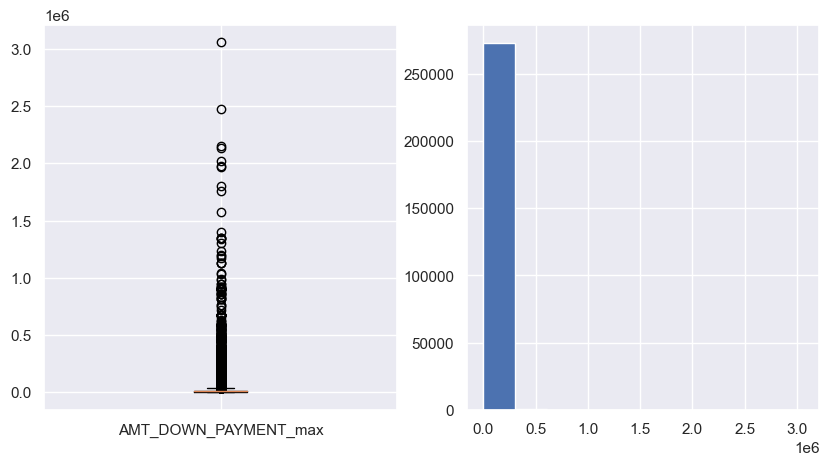

In [32]:
plot_hist_box(numerical_frame, 'AMT_DOWN_PAYMENT_max')

Number of outliers : 595


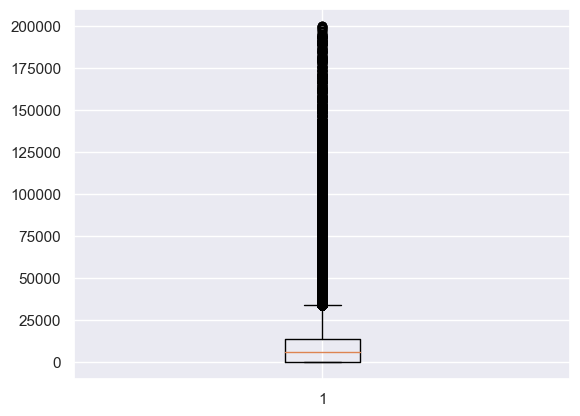

In [33]:
'''
this cell adjusts the outlier range, marks outlier records (nans remain unchanged), and also scales the data to year scale.
'''

plt.boxplot(numerical_frame.loc[numerical_frame['AMT_DOWN_PAYMENT_max']<0.2e6, 'AMT_DOWN_PAYMENT_max']);
numerical_frame['AMT_DOWN_PAYMENT_max_outlier']=0
numerical_frame.loc[numerical_frame['AMT_DOWN_PAYMENT_max']>=0.2e6, 'AMT_DOWN_PAYMENT_max_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_DOWN_PAYMENT_max_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_DOWN_PAYMENT_max_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

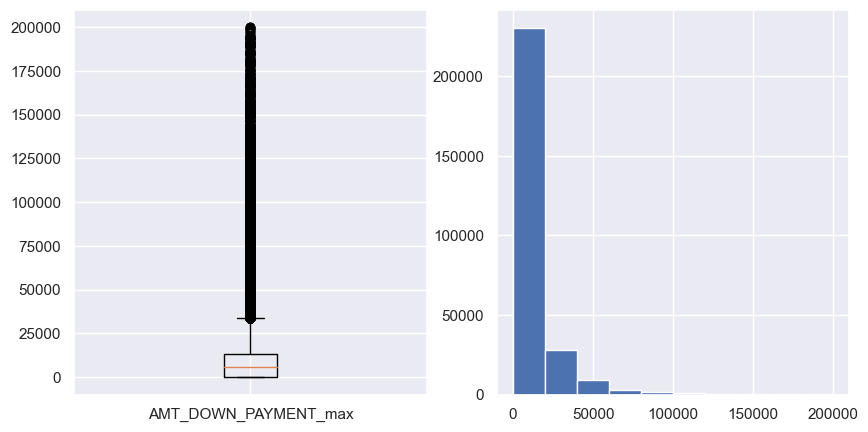

In [34]:
plot_hist_box(good_frame, 'AMT_DOWN_PAYMENT_max')

Median of AMT_DOWN_PAYMENT_max with target=0 : 6048.000000
Median of AMT_DOWN_PAYMENT_max with target=1 : 4500.000000


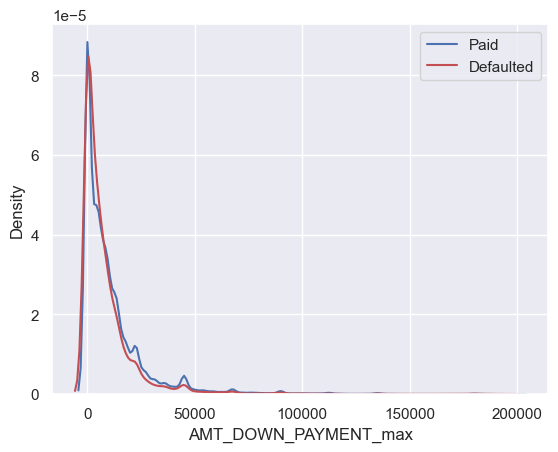

In [35]:
plot_kde_vs_target('AMT_DOWN_PAYMENT_max', good_frame)
median_vs_target('AMT_DOWN_PAYMENT_max', good_frame)

(-0.001, 2430.0]       9.513668
(2430.0, 4500.0]       9.379236
(4500.0, 7195.5]       8.333333
(7195.5, 10350.0]      7.475837
(10350.0, 14841.0]     7.012711
(14841.0, 23850.0]     6.294490
(23850.0, 199953.0]    5.339229
Name: AMT_DOWN_PAYMENT_max_binned, dtype: float64


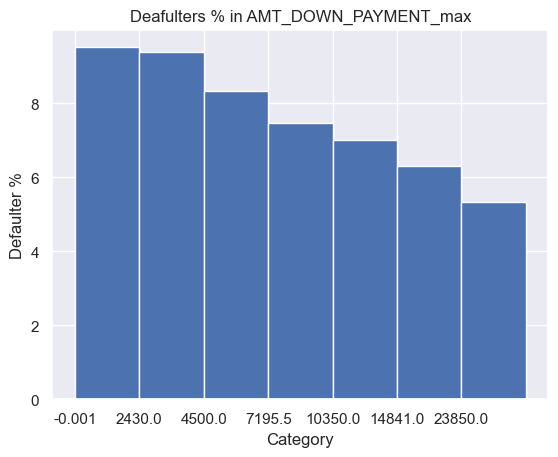

In [36]:
plot_hist_default_pct('AMT_DOWN_PAYMENT_max', good_frame, 9)

### PRODUCT_CARD_STREET

In [59]:
numerical_frame['PRODUCT_CARD_STREET'].isnull().sum()

0

In [60]:
numerical_frame['PRODUCT_CARD_STREET'].describe()

count    291057.000000
mean          0.325002
std           0.765556
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          31.000000
Name: PRODUCT_CARD_STREET, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

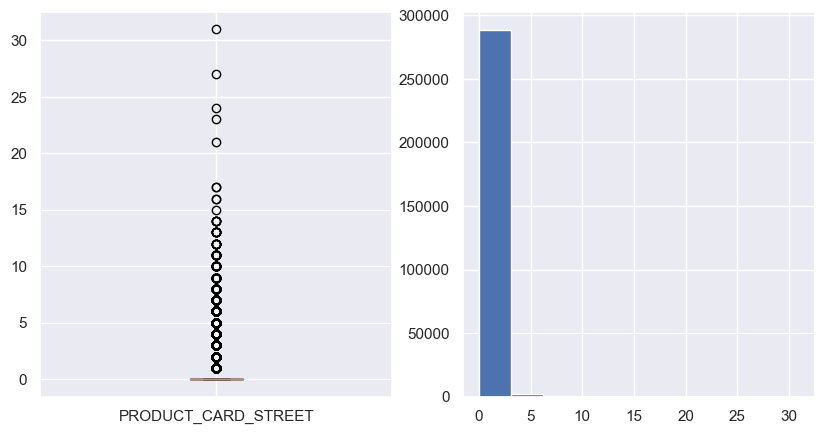

In [61]:
plot_hist_box(numerical_frame, 'PRODUCT_CARD_STREET')

Median of PRODUCT_CARD_STREET with target=0 : 0.000000
Median of PRODUCT_CARD_STREET with target=1 : 0.000000


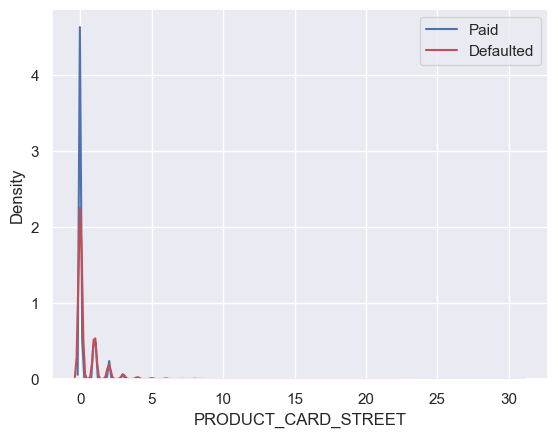

In [62]:
plot_kde_vs_target('PRODUCT_CARD_STREET', numerical_frame)
median_vs_target('PRODUCT_CARD_STREET', numerical_frame)

(-0.001, 1.0]     7.889458
(1.0, 31.0]      12.829703
Name: PRODUCT_CARD_STREET_binned, dtype: float64


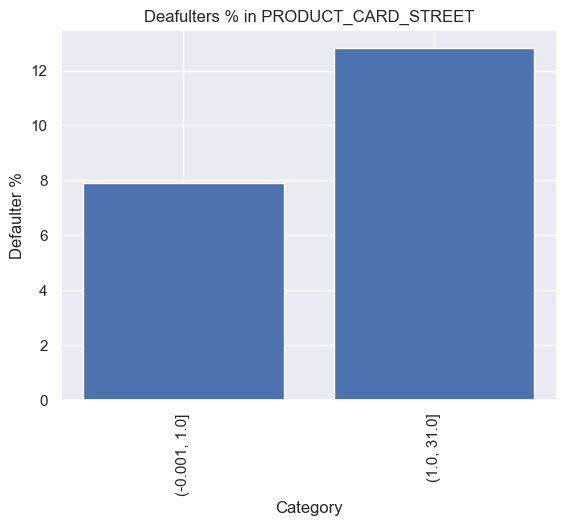

In [63]:
plot_hist_default_pct('PRODUCT_CARD_STREET', numerical_frame, 9)

<Axes: ylabel='PRODUCT_CARD_STREET'>

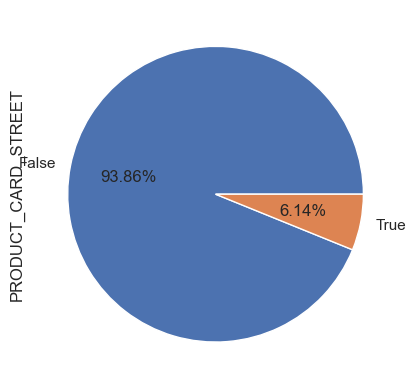

In [112]:
temp=numerical_frame['PRODUCT_CARD_STREET']>1
temp.value_counts().plot.pie(autopct='%1.2f%%')

### PRODUCT_CASH_STREET_HIGH

In [116]:
numerical_frame['PRODUCT_CASH_STREET_HIGH'].isnull().sum()

0

In [117]:
numerical_frame['PRODUCT_CASH_STREET_HIGH'].describe()

count    291057.000000
mean          0.177625
std           0.646679
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          24.000000
Name: PRODUCT_CASH_STREET_HIGH, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

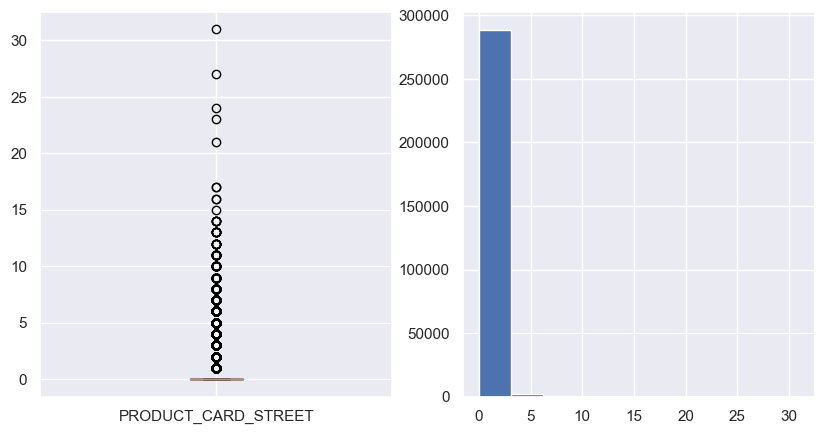

In [118]:
plot_hist_box(numerical_frame, 'PRODUCT_CARD_STREET')

Median of PRODUCT_CASH_STREET_HIGH with target=0 : 0.000000
Median of PRODUCT_CASH_STREET_HIGH with target=1 : 0.000000


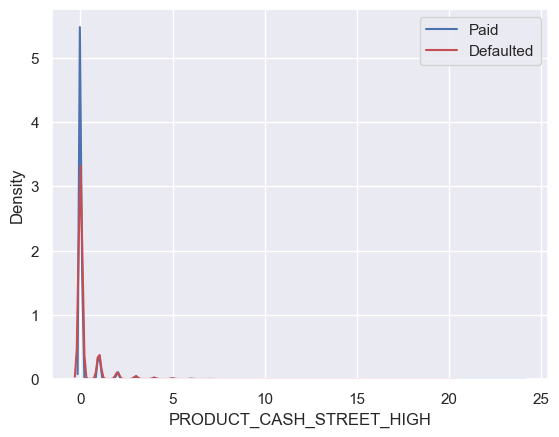

In [119]:
plot_kde_vs_target('PRODUCT_CASH_STREET_HIGH', numerical_frame)
median_vs_target('PRODUCT_CASH_STREET_HIGH', numerical_frame)

(-0.001, 1.0]     8.066679
(1.0, 24.0]      11.771845
Name: PRODUCT_CASH_STREET_HIGH_binned, dtype: float64


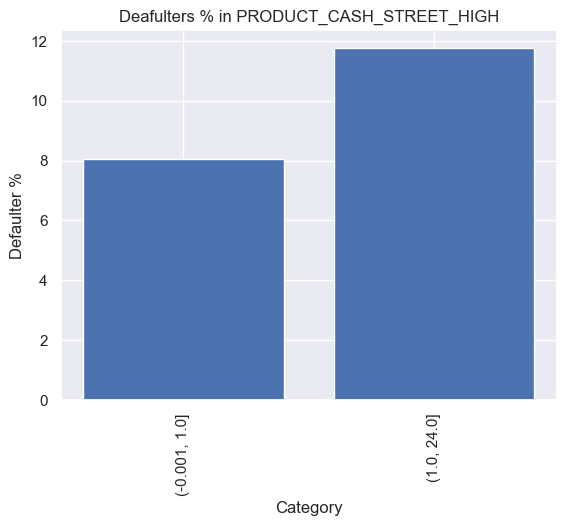

In [120]:
plot_hist_default_pct('PRODUCT_CASH_STREET_HIGH', numerical_frame, 9)

<Axes: ylabel='PRODUCT_CASH_STREET_HIGH'>

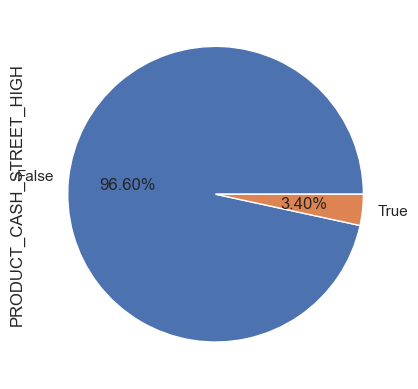

In [121]:
temp=numerical_frame['PRODUCT_CASH_STREET_HIGH']>1
temp.value_counts().plot.pie(autopct='%1.2f%%')

### PRODUCT_CASH_X_SELL_LOW

In [70]:
numerical_frame['PRODUCT_CASH_X_SELL_LOW'].isnull().sum()

0

In [71]:
numerical_frame['PRODUCT_CASH_X_SELL_LOW'].describe()

count    291057.000000
mean          0.379991
std           0.953102
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          25.000000
Name: PRODUCT_CASH_X_SELL_LOW, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

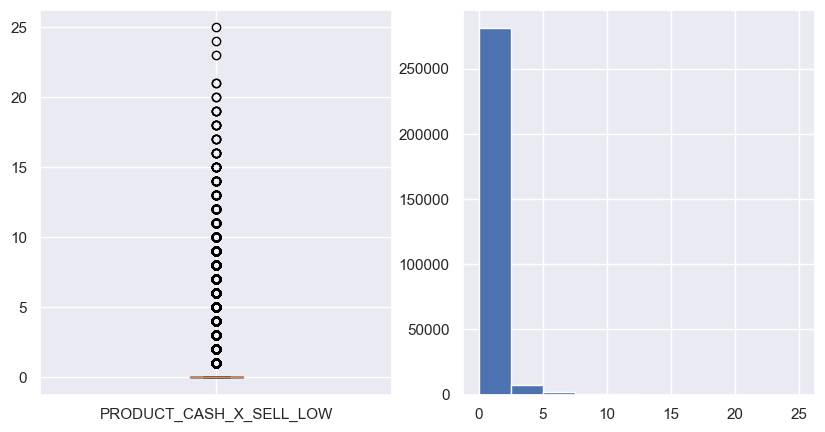

In [72]:
plot_hist_box(numerical_frame, 'PRODUCT_CASH_X_SELL_LOW')

Median of PRODUCT_CASH_X_SELL_LOW with target=0 : 0.000000
Median of PRODUCT_CASH_X_SELL_LOW with target=1 : 0.000000


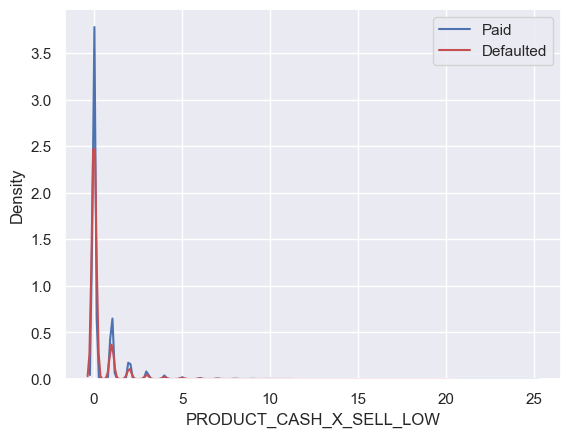

In [73]:
plot_kde_vs_target('PRODUCT_CASH_X_SELL_LOW', numerical_frame)
median_vs_target('PRODUCT_CASH_X_SELL_LOW', numerical_frame)

(-0.001, 1.0]    8.344341
(1.0, 25.0]      6.428107
Name: PRODUCT_CASH_X_SELL_LOW_binned, dtype: float64


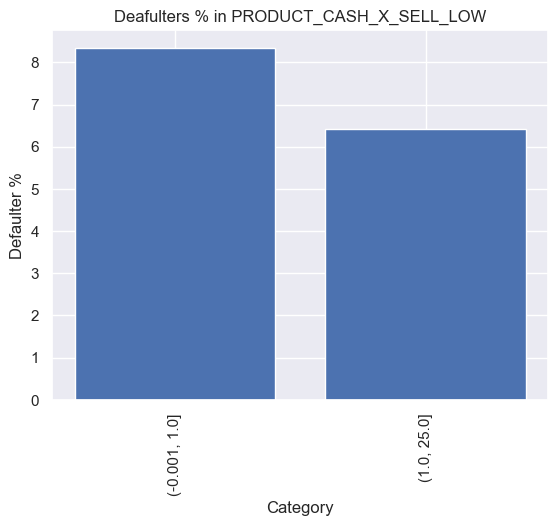

In [75]:
plot_hist_default_pct('PRODUCT_CASH_X_SELL_LOW', numerical_frame, 9)

<Axes: ylabel='PRODUCT_CASH_X_SELL_LOW'>

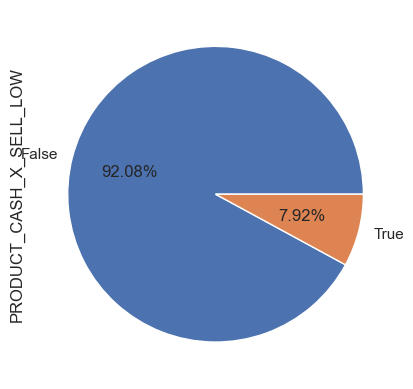

In [114]:
temp=numerical_frame['PRODUCT_CASH_X_SELL_LOW']>1
temp.value_counts().plot.pie(autopct='%1.2f%%')

### RATE_DOWN_PAYMENT_max

In [76]:
numerical_frame['RATE_DOWN_PAYMENT_max'].isnull().sum()

17452

In [77]:
numerical_frame['RATE_DOWN_PAYMENT_max'].describe()

count    273605.000000
mean          0.128002
std           0.131108
min           0.000000
25%           0.000000
50%           0.105282
75%           0.194572
max           1.000000
Name: RATE_DOWN_PAYMENT_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

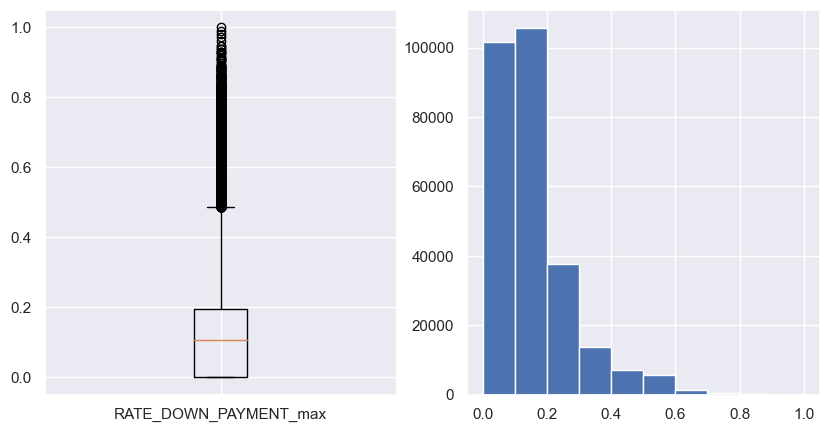

In [78]:
plot_hist_box(numerical_frame, 'RATE_DOWN_PAYMENT_max')

Median of RATE_DOWN_PAYMENT_max with target=0 : 0.105969
Median of RATE_DOWN_PAYMENT_max with target=1 : 0.101433


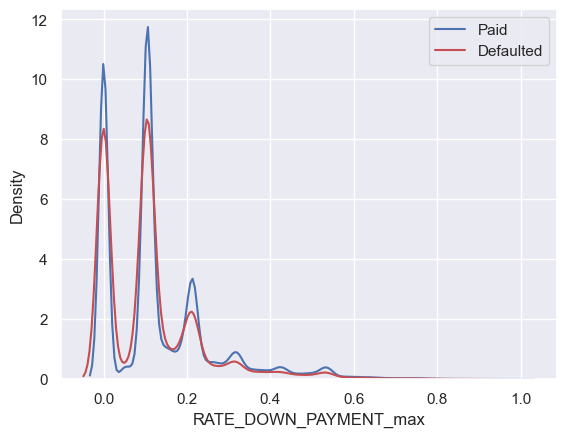

In [79]:
plot_kde_vs_target('RATE_DOWN_PAYMENT_max', numerical_frame)
median_vs_target('RATE_DOWN_PAYMENT_max', numerical_frame)

(-0.001, 0.0946]    9.442775
(0.0946, 0.102]     8.880410
(0.102, 0.109]      7.655759
(0.109, 0.117]      7.115060
(0.117, 0.206]      7.937500
(0.206, 0.285]      6.562500
(0.285, 1.0]        5.838624
Name: RATE_DOWN_PAYMENT_max_binned, dtype: float64


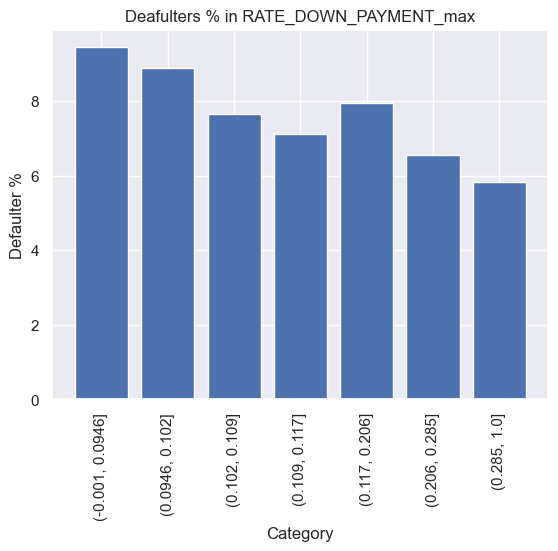

In [80]:
plot_hist_default_pct('RATE_DOWN_PAYMENT_max', numerical_frame, 9)

### REJECT_HC

In [81]:
numerical_frame['REJECT_HC'].isnull().sum()

0

In [82]:
numerical_frame['REJECT_HC'].describe()

count    291057.000000
mean          0.501565
std           1.376144
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          58.000000
Name: REJECT_HC, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

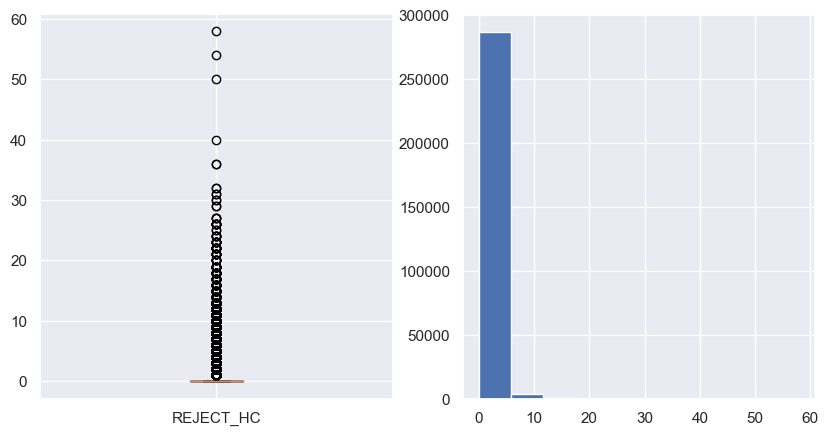

In [83]:
plot_hist_box(numerical_frame, 'REJECT_HC')

Median of REJECT_HC with target=0 : 0.000000
Median of REJECT_HC with target=1 : 0.000000


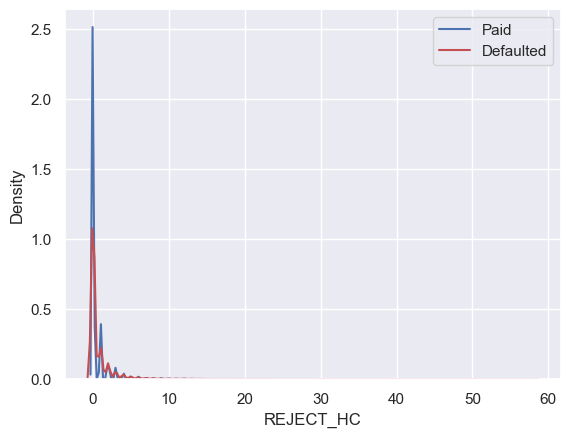

In [84]:
plot_kde_vs_target('REJECT_HC', numerical_frame)
median_vs_target('REJECT_HC', numerical_frame)

(-0.001, 1.0]     7.776943
(1.0, 58.0]      11.619338
Name: REJECT_HC_binned, dtype: float64


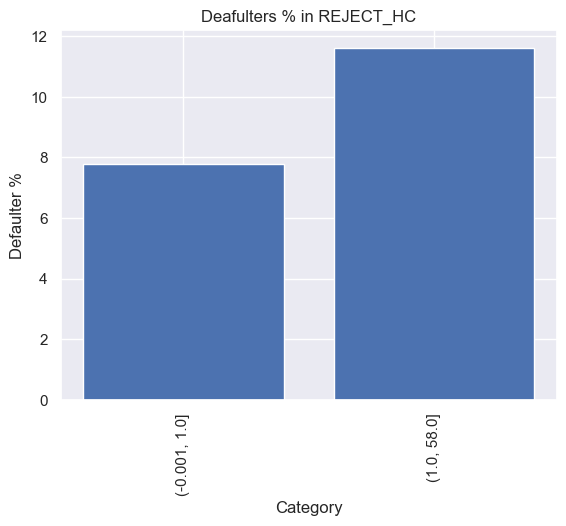

In [85]:
plot_hist_default_pct('REJECT_HC', numerical_frame, 9)

<Axes: ylabel='REJECT_HC'>

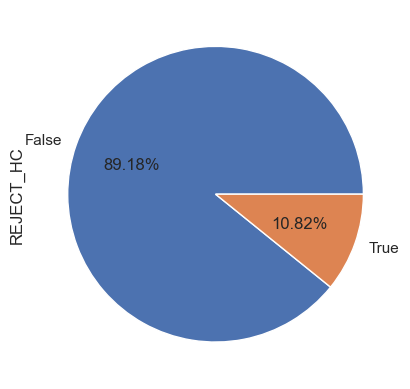

In [113]:
temp=numerical_frame['REJECT_HC']>1
temp.value_counts().plot.pie(autopct='%1.2f%%')

### SELLERPLACE_AREA_max

In [86]:
numerical_frame['SELLERPLACE_AREA_max'].isnull().sum()

0

In [87]:
numerical_frame['SELLERPLACE_AREA_max'].describe()

count    2.910570e+05
mean     9.679794e+02
std      1.683950e+04
min     -1.000000e+00
25%      5.000000e+01
50%      1.580000e+02
75%      1.168000e+03
max      4.000000e+06
Name: SELLERPLACE_AREA_max, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

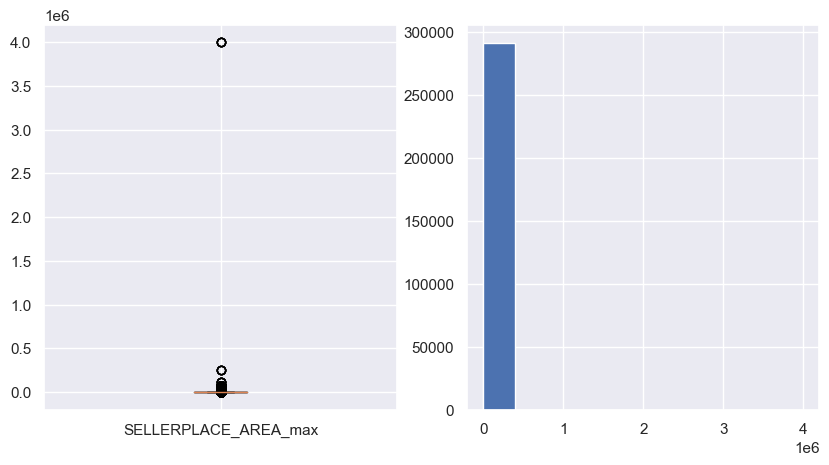

In [88]:
plot_hist_box(numerical_frame, 'SELLERPLACE_AREA_max')

Number of outliers : 1573


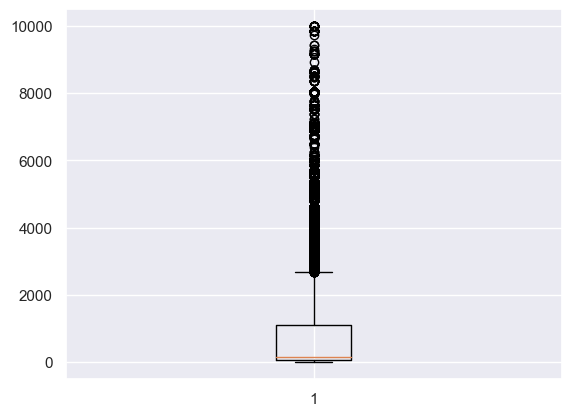

In [95]:
'''
this cell adjusts the outlier range, marks outlier records (nans remain unchanged), and also scales the data to year scale.
'''

plt.boxplot(numerical_frame.loc[numerical_frame['SELLERPLACE_AREA_max']<1e4, 'SELLERPLACE_AREA_max']);
numerical_frame['SELLERPLACE_AREA_max_outlier']=0
numerical_frame.loc[numerical_frame['SELLERPLACE_AREA_max']>=1e4, 'SELLERPLACE_AREA_max_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['SELLERPLACE_AREA_max_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['SELLERPLACE_AREA_max_outlier']==1).sum()))

array([<Axes: >, <Axes: >], dtype=object)

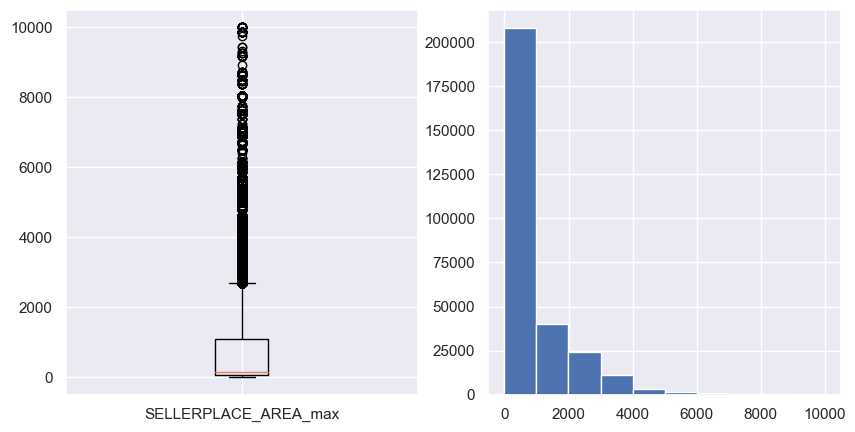

In [96]:
plot_hist_box(good_frame, 'SELLERPLACE_AREA_max')

Median of SELLERPLACE_AREA_max with target=0 : 160.000000
Median of SELLERPLACE_AREA_max with target=1 : 138.000000


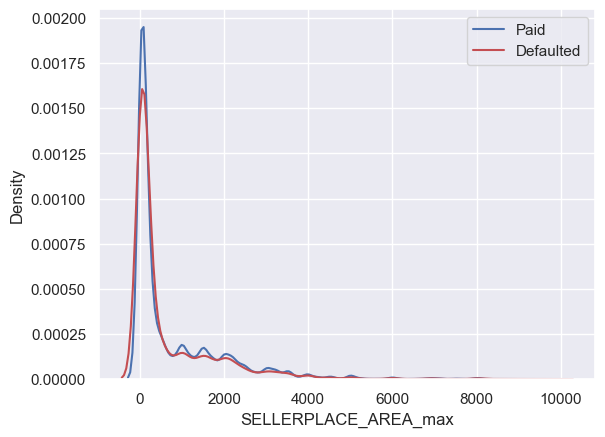

In [97]:
plot_kde_vs_target('SELLERPLACE_AREA_max', good_frame)
median_vs_target('SELLERPLACE_AREA_max', good_frame)

(-1.001, 20.0]      9.249202
(20.0, 40.0]        9.828077
(40.0, 70.0]        9.249558
(70.0, 133.0]       8.224893
(133.0, 232.0]      8.171629
(232.0, 584.0]      7.624806
(584.0, 1350.0]     7.355004
(1350.0, 2178.0]    7.283678
(2178.0, 9999.0]    6.853631
Name: SELLERPLACE_AREA_max_binned, dtype: float64


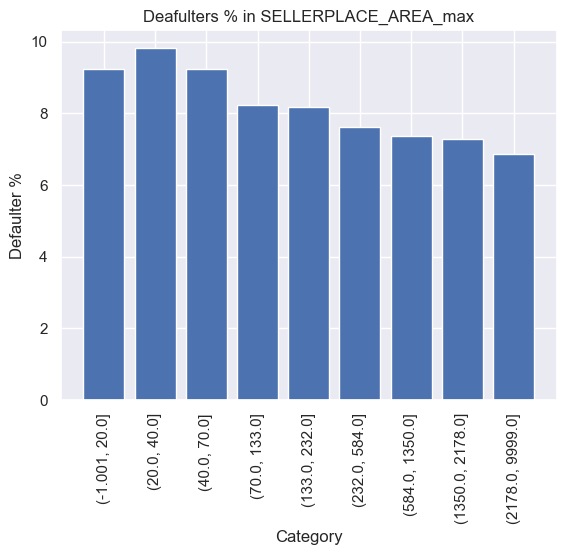

In [102]:
plot_hist_default_pct('SELLERPLACE_AREA_max', good_frame, 9)

### YIELD_XNA

In [103]:
numerical_frame['YIELD_XNA'].isnull().sum()

0

In [104]:
numerical_frame['YIELD_XNA'].describe()

count    291057.000000
mean          1.474618
std           2.153610
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          62.000000
Name: YIELD_XNA, dtype: float64

array([<Axes: >, <Axes: >], dtype=object)

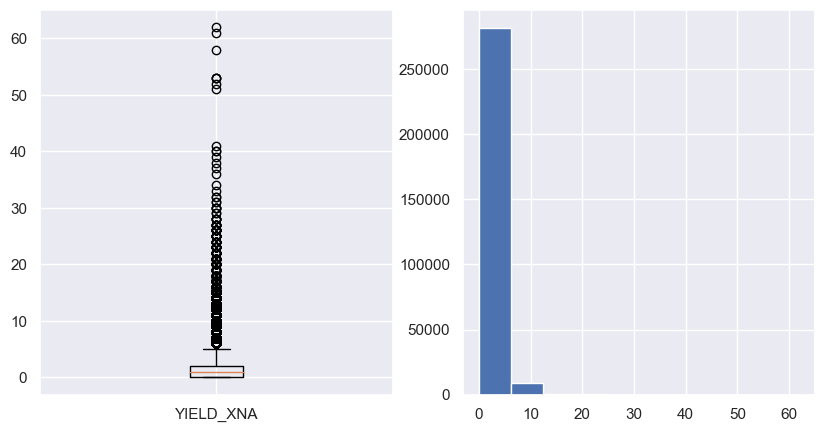

In [105]:
plot_hist_box(numerical_frame, 'YIELD_XNA')

Median of YIELD_XNA with target=0 : 1.000000
Median of YIELD_XNA with target=1 : 1.000000


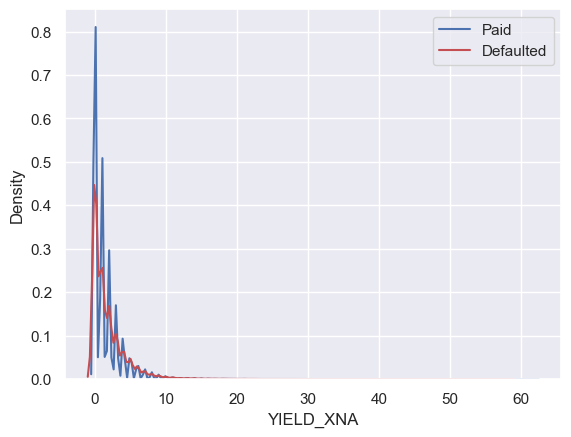

In [106]:
plot_kde_vs_target('YIELD_XNA', numerical_frame)
median_vs_target('YIELD_XNA', numerical_frame)

(-0.001, 1.0]     7.506564
(1.0, 2.0]        8.661480
(2.0, 4.0]        9.395468
(4.0, 62.0]      11.270614
Name: YIELD_XNA_binned, dtype: float64


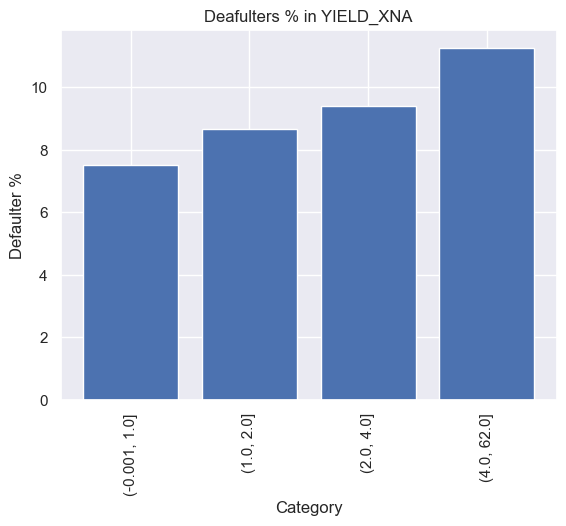

In [107]:
plot_hist_default_pct('YIELD_XNA', numerical_frame, 9)

### Dropping Unipmortant Variables

In [123]:
numerical_frame.drop(labels=['PRODUCT_CASH_STREET_HIGH'], axis=1, inplace=True)
numerical_frame.columns.sort_values()

Index(['AMT_DOWN_PAYMENT_max', 'AMT_DOWN_PAYMENT_max_outlier',
       'PRODUCT_CARD_STREET', 'PRODUCT_CASH_X_SELL_LOW',
       'RATE_DOWN_PAYMENT_max', 'REJECT_HC', 'SELLERPLACE_AREA_max',
       'SELLERPLACE_AREA_max_outlier', 'SK_ID_CURR', 'TARGET', 'YIELD_XNA'],
      dtype='object')

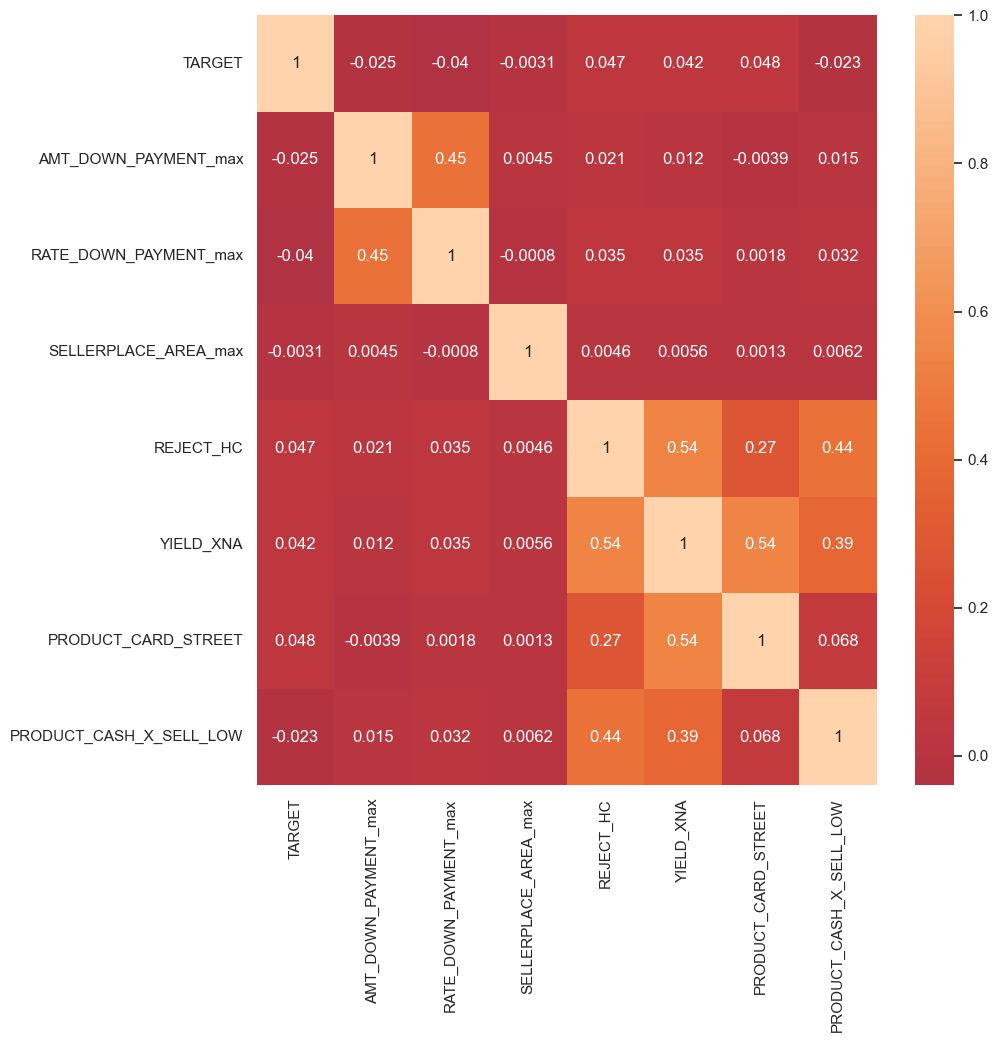

In [125]:
ax=sns.heatmap(numerical_frame.drop(labels=['SK_ID_CURR', 'AMT_DOWN_PAYMENT_max_outlier',
                                            'SELLERPLACE_AREA_max_outlier'], 
                                    axis=1).corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=10, h=10)


In [126]:
# numerical_frame.to_csv('initial_clean_prev_app.csv', index=False)